# 🧪 DealPOS API — Exploratory Data Analysis (EDA)

> **Purpose:** Fetch data from every major DealPOS GET/POST endpoint and perform EDA — shapes, dtypes, missing values, distributions, and visualizations.
>
> **API Version:** 3.1.0 | Base URL: `https://{subdomain}/api/v3/`

## 0. Setup & Authentication

Install dependencies if not already present:
```bash
pip install requests pandas matplotlib seaborn plotly
```

In [73]:
import requests

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import matplotlib.ticker as mticker

import seaborn as sns

import warnings

from IPython.display import display, Markdown

from datetime import datetime, timedelta



warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

pd.set_option('display.max_colwidth', 60)



# ── Styling ──

plt.rcParams.update({

    'figure.facecolor': '#0f172a',

    'axes.facecolor':   '#1e293b',

    'axes.edgecolor':   '#334155',

    'axes.labelcolor':  '#94a3b8',

    'text.color':       '#e2e8f0',

    'xtick.color':      '#64748b',

    'ytick.color':      '#64748b',

    'grid.color':       '#1e293b',

    'figure.titlesize': 14,

})

sns.set_theme(style='darkgrid')

ACCENT = '#0ea5e9'

PALETTE = ['#0ea5e9','#10b981','#f59e0b','#ef4444','#7c3aed','#f472b6']



print('✅ Libraries loaded')

✅ Libraries loaded


### Credentials

In [74]:
# ── Fill in your credentials ──

SUBDOMAIN     = 'hijacksandals.dealpos.net'   # e.g. mybrand.dealpos.net

CLIENT_ID     = '019c9a25-05c4-7a38-b04a-dd1efe4c08ef'                             # paste your Client ID

CLIENT_SECRET = '019c9a26-51bf-7232-ae0a-4c702ba345e9'                             # paste your Client Secret



DATE_FROM = (datetime.today() - timedelta(days=30)).strftime('%Y-%m-%d')

DATE_TO   = datetime.today().strftime('%Y-%m-%d')

BASE_URL  = f'https://{SUBDOMAIN}/api/v3'



print(f'Base URL : {BASE_URL}')

print(f'Period   : {DATE_FROM} → {DATE_TO}')

Base URL : https://hijacksandals.dealpos.net/api/v3
Period   : 2026-02-02 → 2026-03-04


### Token + Helper Functions

In [75]:
def get_token():

    res = requests.post(

        f'{BASE_URL}/Token/OAuth2',

        json={'client_id': CLIENT_ID, 'client_secret': CLIENT_SECRET},

        timeout=15

    )

    res.raise_for_status()

    data = res.json()

    tok = data.get('access_token') or data.get('AccessToken') or data.get('token')

    print(f'✅ Token obtained — expires: {data.get("expiredAt", "N/A")}')

    return tok



TOKEN = get_token()

HEADERS = {'Authorization': f'Bearer {TOKEN}'}

✅ Token obtained — expires: 2026-03-06T14:29:57.3563968+07:00


In [76]:
def api_get(path, params=None):

    """GET request with error handling."""

    try:

        r = requests.get(f'{BASE_URL}{path}', headers=HEADERS, params=params or {}, timeout=20)

        r.raise_for_status()

        return r.json()

    except Exception as e:

        print(f'⚠️  GET {path} failed: {e}')

        return None



def api_post(path, body=None):

    """POST request with error handling."""

    try:

        r = requests.post(f'{BASE_URL}{path}', headers=HEADERS, json=body or {}, timeout=20)

        r.raise_for_status()

        return r.json()

    except Exception as e:

        print(f'⚠️  POST {path} failed: {e}')

        return None



def to_df(data, keys=None):

    """Safely convert API response to DataFrame."""

    if data is None: return pd.DataFrame()

    if isinstance(data, list): rows = data

    elif isinstance(data, dict):

        for k in (keys or ['Data','data','Result','result','Items','items']):

            if k in data: rows = data[k]; break

        else: rows = [data]

    else: return pd.DataFrame()

    return pd.DataFrame(rows) if rows else pd.DataFrame()



def eda(df, title=''):

    """Print a standard EDA summary for a DataFrame."""

    if df.empty:

        print(f'⚠️  [{title}] — Empty DataFrame, no data to analyse.')

        return

    display(Markdown(f'#### 📋 {title}'))

    print(f'Shape       : {df.shape[0]:,} rows × {df.shape[1]} columns')

    print(f'Columns     : {list(df.columns)}')

    display(df.dtypes.rename('dtype').to_frame())

    null_pct = (df.isnull().sum() / len(df) * 100).rename('null_%').round(2)

    display(null_pct[null_pct > 0].to_frame() if null_pct.any() else pd.DataFrame({'null_%': ['(none)']}))

    print('\n--- Head ---')

    display(df.head(5))

    num_cols = df.select_dtypes(include='number').columns.tolist()

    if num_cols:

        print('\n--- Numeric Summary ---')

        display(df[num_cols].describe().T)



def plot_bar(series, title, xlabel='', ylabel='Count', top_n=15, color=ACCENT):

    """Horizontal bar chart of a value_counts series."""

    data = series.value_counts().head(top_n)

    fig, ax = plt.subplots(figsize=(9, max(3, len(data)*0.45)))

    ax.barh(data.index.astype(str)[::-1], data.values[::-1], color=color)

    ax.set_title(title, color='#e2e8f0', pad=10)

    ax.set_xlabel(ylabel, color='#94a3b8')

    ax.set_ylabel(xlabel, color='#94a3b8')

    plt.tight_layout(); plt.show()



def plot_hist(series, title, color=ACCENT, bins=20):

    """Histogram for a numeric series."""

    series = pd.to_numeric(series, errors='coerce').dropna()

    if series.empty: print(f'No numeric data for: {title}'); return

    fig, ax = plt.subplots(figsize=(9, 4))

    ax.hist(series, bins=bins, color=color, edgecolor='#0f172a')

    ax.set_title(title, color='#e2e8f0', pad=10)

    ax.set_xlabel(series.name or '', color='#94a3b8')

    ax.set_ylabel('Frequency', color='#94a3b8')

    plt.tight_layout(); plt.show()



def plot_time(df, date_col, val_col=None, title='Time Series', freq='D', color=ACCENT):

    """Line chart grouped by date."""

    if df.empty or date_col not in df.columns: return

    df = df.copy()

    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

    df = df.dropna(subset=[date_col])

    if val_col and val_col in df.columns:

        df[val_col] = pd.to_numeric(df[val_col], errors='coerce')

        ts = df.groupby(df[date_col].dt.to_period(freq))[val_col].sum()

    else:

        ts = df.groupby(df[date_col].dt.to_period(freq)).size()

        val_col = 'Count'

    ts.index = ts.index.astype(str)

    fig, ax = plt.subplots(figsize=(11, 4))

    ax.plot(ts.index, ts.values, color=color, linewidth=2, marker='o', markersize=3)

    ax.fill_between(ts.index, ts.values, alpha=0.15, color=color)

    ax.set_title(title, color='#e2e8f0', pad=10)

    ax.set_ylabel(val_col, color='#94a3b8')

    plt.xticks(rotation=45, ha='right')

    plt.tight_layout(); plt.show()



print('✅ Helper functions ready')

✅ Helper functions ready


## 1. 🗂️ Category

**Endpoints:** `GET /Category` · `GET /Category/ID`

In [77]:
cat_data = api_get('/Category')

cat_df   = to_df(cat_data)

eda(cat_df, 'Category')

#### 📋 Category

Shape       : 29 rows × 3 columns
Columns     : ['ID', 'Name', 'Discontinued']


,dtype
ID,object
Name,object
Discontinued,bool


,null_%
0,(none)



--- Head ---


,ID,Name,Discontinued
0,6c5b3746-0ece-40a9-a436-329be1362a1f,Akross,True
1,5fd3bf01-8f75-4c72-a706-75311c411913,Akross/Sandals,True
2,bc317488-e462-4ad7-954e-677eea16b2ef,Akross/Shoes,True
3,f1be5cfe-399f-4fa9-83e9-76e9eb775503,FNB,True
4,f85218b6-29f5-4b87-967c-a1f5cdce7125,Hijacksandals,False


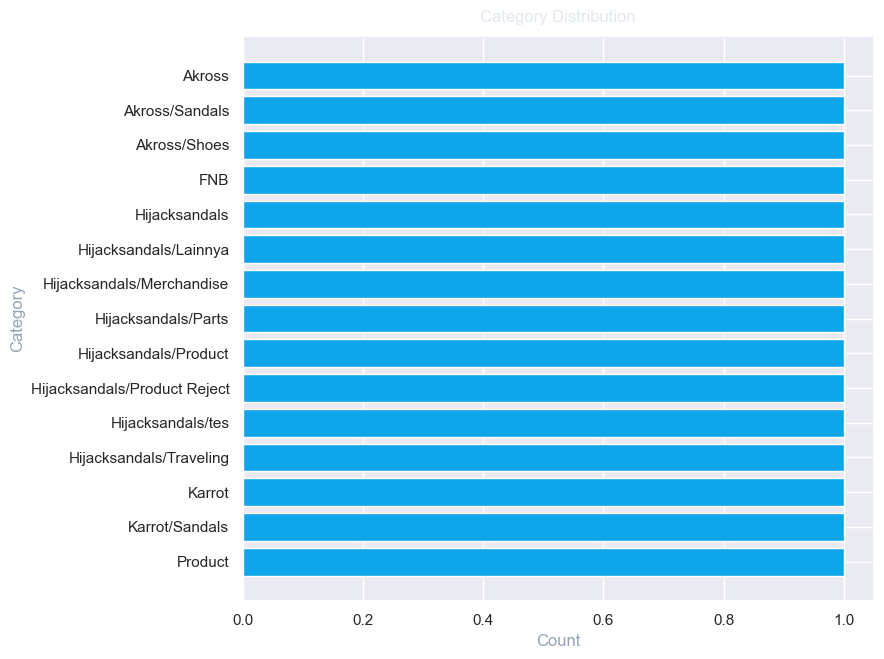

In [78]:
if not cat_df.empty:

    name_col = next((c for c in cat_df.columns if 'name' in c.lower()), None)

    if name_col:

        plot_bar(cat_df[name_col], 'Category Distribution', xlabel='Category', color=PALETTE[0])

    

    parent_col = next((c for c in cat_df.columns if 'parent' in c.lower()), None)

    if parent_col:

        plot_bar(cat_df[parent_col].fillna('(root)'), 'Categories by Parent', color=PALETTE[1])

    

    # Missing values heatmap

    if cat_df.isnull().any().any():

        fig, ax = plt.subplots(figsize=(10, 3))

        sns.heatmap(cat_df.isnull(), cbar=False, yticklabels=False, ax=ax, cmap='Blues')

        ax.set_title('Category — Null Value Map', color='#e2e8f0')

        plt.tight_layout(); plt.show()

## 2. 📦 Product

**Endpoints:** `GET /Product` · `GET /Product/Code` · `GET /Product/ID`

In [79]:
prod_data = api_get('/Product', {'PageNumber': 2, 'PageSize': 20})

prod_df   = to_df(prod_data)

# eda(prod_df, 'Product')
prod_data

{'DataArray': [{'ID': '0199a313-2eeb-79ae-bf2e-9a88e1a2ff31',
   'Name': 'OAKEN - Eau De Parfum 50ml - Temple Moss',
   'Code': 'OAK-EDP-008',
   'Category': 'Hijacksandals/Lainnya',
   'Released': '2025-10-02T00:00:00',
   'ThumbnailUrl': None,
   'ImageUrl': None,
   'Discontinued': False,
   'Variants': [{'ID': '0199a313-a39d-724d-ab41-dd4877853739',
     'Model': 'Default',
     'Code': 'OAK-EDP-008',
     'UnitPrice': 899000,
     'Discontinued': False,
     'ProductID': '0199a313-2eeb-79ae-bf2e-9a88e1a2ff31',
     'Weight': None,
     'Discount': 0,
     'TypeID': 1,
     'ProductIndex': 0}],
   'Created': '2025-10-02T10:59:57.323',
   'CostCurrencyID': 1},
  {'ID': '0199a310-4b87-7f2f-894b-49b47f8af2ef',
   'Name': 'OAKEN - Eau De Parfum 50ml - Narikela',
   'Code': 'OAK-EDP-007',
   'Category': 'Hijacksandals/Lainnya',
   'Released': '2025-10-02T00:00:00',
   'ThumbnailUrl': None,
   'ImageUrl': None,
   'Discontinued': False,
   'Variants': [{'ID': '0199a312-cc10-7e67-8f7d-415

In [80]:
if not prod_df.empty:

    cat_col  = next((c for c in prod_df.columns if 'category' in c.lower()), None)

    type_col = next((c for c in prod_df.columns if 'type' in c.lower()), None)

    price_col= next((c for c in prod_df.columns if 'price' in c.lower()), None)

    

    if cat_col:

        plot_bar(prod_df[cat_col], 'Products per Category', color=PALETTE[0])

    if type_col:

        plot_bar(prod_df[type_col], 'Products by Type', color=PALETTE[2])

    if price_col:

        plot_hist(prod_df[price_col], f'Price Distribution ({price_col})', color=PALETTE[1])

    

    # Correlation of numeric fields

    num_cols = prod_df.select_dtypes(include='number').columns

    if len(num_cols) > 1:

        fig, ax = plt.subplots(figsize=(8, 6))

        corr = prod_df[num_cols].corr()

        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,

                    linewidths=0.5, linecolor='#0f172a')

        ax.set_title('Product — Numeric Correlation', color='#e2e8f0')

        plt.tight_layout(); plt.show()

## 3. 🔖 Variant

**Endpoints:** `GET /Variant` · `GET /Variant/Data` · `GET /Variant/Count`

In [81]:
var_data  = api_get('/Variant', {'Page': 1, 'Limit': 500})

var_df    = to_df(var_data)

var_count = api_get('/Variant/Count')

print(f'Total variants (API count): {var_count}')

eda(var_df, 'Variant')

Total variants (API count): {'Count': 7661}


#### 📋 Variant

Shape       : 10 rows × 6 columns
Columns     : ['ID', 'Name', 'Code', 'Type', 'UnitPrice', 'UnitCost']


,dtype
ID,object
Name,object
Code,object
Type,object
UnitPrice,int64
UnitCost,int64


,null_%
0,(none)



--- Head ---


,ID,Name,Code,Type,UnitPrice,UnitCost
0,f3da2d61-85ff-448f-bb30-d84910f162e0,Dali Rope,,Standard,19000,7000
1,81844d61-598b-44a5-837b-ece8d3424522,DHL,,Standard,0,0
2,15318ff4-025e-40da-b928-ff1cbda5301a,HERONA EXPRESS,,NonInventory,50000,50
3,4e0d1f45-752f-48fe-9e1c-c0d7c9f7d898,JNE REG,,Standard,10000,0
4,c5463744-8a64-4adc-864b-4604f1904f09,JNE YES,,Standard,15000,0



--- Numeric Summary ---


,count,mean,std,min,25%,50%,75%,max
UnitPrice,10.0,10900.0,15715.880150,0.0,0.0,5000.0,15000.0,50000.0
UnitCost,10.0,705.0,2211.893357,0.0,0.0,0.0,0.0,7000.0


In [13]:
if not var_df.empty:

    unit_col  = next((c for c in var_df.columns if 'unit' in c.lower()), None)

    price_col = next((c for c in var_df.columns if 'price' in c.lower() or 'retail' in c.lower()), None)

    cost_col  = next((c for c in var_df.columns if 'cost' in c.lower()), None)

    

    if unit_col:

        plot_bar(var_df[unit_col], 'Variants by Unit', color=PALETTE[3])

    if price_col:

        plot_hist(var_df[price_col], 'Variant Retail Price Distribution', color=PALETTE[0])

    if price_col and cost_col:

        var_df['_margin'] = pd.to_numeric(var_df[price_col], errors='coerce') - \

                            pd.to_numeric(var_df[cost_col], errors='coerce')

        plot_hist(var_df['_margin'], 'Gross Margin Distribution (Price - Cost)', color=PALETTE[1])

SyntaxError: invalid syntax (457321601.py, line 22)

## 4. 🔢 Serial

**Endpoints:** `GET /Serial` · `GET /Serial/byVariantCode`

In [14]:
serial_data = api_get('/Serial', {'PageNumber': 1, 'PageSize': 200})

serial_df   = to_df(serial_data)

# eda(serial_df, 'Serial')
serial_data

⚠️  GET /Serial failed: name 'HEADERS' is not defined


In [15]:

if not serial_df.empty:

    status_col = next((c for c in serial_df.columns if 'status' in c.lower() or 'state' in c.lower()), None)

    outlet_col = next((c for c in serial_df.columns if 'outlet' in c.lower()), None)

    date_col   = next((c for c in serial_df.columns if 'date' in c.lower() or 'created' in c.lower()), None)

    

    if status_col: plot_bar(serial_df[status_col], 'Serial Status Distribution', color=PALETTE[4])

    if outlet_col: plot_bar(serial_df[outlet_col], 'Serials by Outlet', color=PALETTE[2])

    if date_col:   plot_time(serial_df, date_col, title='Serial Records Over Time')

## 5. 🧾 Invoice

**Endpoints:** `GET /Invoice/MultipleOutlet/WithTotalCount` · `GET /Invoice/Number` · `GET /Invoice/Return`

In [16]:
inv_params = {'DateFrom': DATE_FROM, 'DateTo': DATE_TO}

inv_data   = api_get('/Invoice/MultipleOutlet/WithTotalCount', inv_params)

inv_df     = to_df(inv_data)

eda(inv_df, 'Invoice')

⚠️  GET /Invoice/MultipleOutlet/WithTotalCount failed: name 'HEADERS' is not defined
⚠️  [Invoice] — Empty DataFrame, no data to analyse.


In [17]:
if not inv_df.empty:

    date_col   = next((c for c in inv_df.columns if 'date' in c.lower()), None)

    total_col  = next((c for c in inv_df.columns if 'grand' in c.lower() or 'total' in c.lower()), None)

    outlet_col = next((c for c in inv_df.columns if 'outlet' in c.lower()), None)

    status_col = next((c for c in inv_df.columns if 'status' in c.lower() or 'state' in c.lower()), None)

    cust_col   = next((c for c in inv_df.columns if 'customer' in c.lower() or 'email' in c.lower()), None)

    

    if total_col:

        inv_df[total_col] = pd.to_numeric(inv_df[total_col], errors='coerce')

        plot_hist(inv_df[total_col], 'Invoice Grand Total Distribution', color=PALETTE[0])

        

        # Revenue trend

        if date_col:

            plot_time(inv_df, date_col, total_col, 'Daily Revenue Trend', color=PALETTE[0])

    

    if outlet_col: plot_bar(inv_df[outlet_col], 'Invoices by Outlet', color=PALETTE[1])

    if status_col: plot_bar(inv_df[status_col], 'Invoice Status Breakdown', color=PALETTE[2])

    if cust_col:

        top_customers = inv_df[cust_col].value_counts().head(15)

        plot_bar(inv_df[cust_col], 'Top 15 Customers by Invoice Count', color=PALETTE[3])

    

    # Box plot of totals by outlet

    if outlet_col and total_col:

        top_outlets = inv_df[outlet_col].value_counts().head(6).index

        subset = inv_df[inv_df[outlet_col].isin(top_outlets)]

        fig, ax = plt.subplots(figsize=(10, 5))

        subset.boxplot(column=total_col, by=outlet_col, ax=ax,

                       boxprops=dict(color=ACCENT),

                       medianprops=dict(color='#f59e0b'),

                       whiskerprops=dict(color=ACCENT),

                       capprops=dict(color=ACCENT))

        ax.set_title('Invoice Total Distribution by Outlet', color='#e2e8f0')

        plt.suptitle('')

        plt.xticks(rotation=30, ha='right')

        plt.tight_layout(); plt.show()

#### Invoice Returns

In [18]:
ret_data = api_get('/Invoice/Return', inv_params)

ret_df   = to_df(ret_data)

eda(ret_df, 'Invoice Return')

if not ret_df.empty:

    date_col = next((c for c in ret_df.columns if 'date' in c.lower()), None)

    if date_col: plot_time(ret_df, date_col, title='Returns Over Time', color=PALETTE[3])

⚠️  GET /Invoice/Return failed: name 'HEADERS' is not defined
⚠️  [Invoice Return] — Empty DataFrame, no data to analyse.


## 6. 📋 Sales Order

**Endpoints:** `GET /SalesOrder/TotalCount` · `GET /SalesOrder/GetParked` · `GET /SalesOrder/GetNextNumber`

In [19]:
so_params    = {'DateFrom': DATE_FROM, 'DateTo': DATE_TO}

so_count     = api_get('/SalesOrder/TotalCount', so_params)

so_parked    = api_get('/SalesOrder/GetParked', so_params)

so_nextnum   = api_get('/SalesOrder/GetNextNumber')

so_parked_df = to_df(so_parked)



print(f'Total Sales Orders : {so_count}')

print(f'Next SO Number     : {so_nextnum}')

eda(so_parked_df, 'Parked Sales Orders')

⚠️  GET /SalesOrder/TotalCount failed: name 'HEADERS' is not defined
⚠️  GET /SalesOrder/GetParked failed: name 'HEADERS' is not defined
⚠️  GET /SalesOrder/GetNextNumber failed: name 'HEADERS' is not defined
Total Sales Orders : None
Next SO Number     : None
⚠️  [Parked Sales Orders] — Empty DataFrame, no data to analyse.


In [20]:
if not so_parked_df.empty:

    outlet_col = next((c for c in so_parked_df.columns if 'outlet' in c.lower()), None)

    date_col   = next((c for c in so_parked_df.columns if 'date' in c.lower()), None)

    total_col  = next((c for c in so_parked_df.columns if 'total' in c.lower() or 'amount' in c.lower()), None)

    

    if outlet_col: plot_bar(so_parked_df[outlet_col], 'Parked Orders by Outlet', color=PALETTE[4])

    if total_col:  plot_hist(so_parked_df[total_col], 'Parked Order Value Distribution', color=PALETTE[2])

    if date_col:   plot_time(so_parked_df, date_col, total_col, 'Parked Orders Over Time', color=PALETTE[4])

## 7. 📝 Estimate

**Endpoints:** `GET /Estimate` · `GET /Estimate/Detail` · `GET /Estimate/WithTotalCount`

In [21]:
est_data = api_get('/Estimate/WithTotalCount', {'DateFrom': DATE_FROM, 'DateTo': DATE_TO})

est_df   = to_df(est_data)

eda(est_df, 'Estimate')

⚠️  GET /Estimate/WithTotalCount failed: name 'HEADERS' is not defined
⚠️  [Estimate] — Empty DataFrame, no data to analyse.


In [22]:
if not est_df.empty:

    date_col   = next((c for c in est_df.columns if 'date' in c.lower()), None)

    total_col  = next((c for c in est_df.columns if 'total' in c.lower()), None)

    status_col = next((c for c in est_df.columns if 'status' in c.lower()), None)

    outlet_col = next((c for c in est_df.columns if 'outlet' in c.lower()), None)

    

    if status_col: plot_bar(est_df[status_col], 'Estimate Status Breakdown', color=PALETTE[2])

    if outlet_col: plot_bar(est_df[outlet_col], 'Estimates by Outlet', color=PALETTE[0])

    if total_col:  plot_hist(est_df[total_col], 'Estimate Total Distribution', color=PALETTE[1])

    if date_col:   plot_time(est_df, date_col, total_col, 'Estimates Over Time', color=PALETTE[2])

## 8. ⏱️ Shift

**Endpoints:** `GET /Shift` · `GET /Shift/TotalCount` · `GET /Shift/Number`

In [23]:
shift_params = {'DateFrom': DATE_FROM, 'DateTo': DATE_TO}

shift_data   = api_get('/Shift', shift_params)

shift_df     = to_df(shift_data)

shift_count  = api_get('/Shift/TotalCount', shift_params)

print(f'Total shifts: {shift_count}')

eda(shift_df, 'Shift')

⚠️  GET /Shift failed: name 'HEADERS' is not defined
⚠️  GET /Shift/TotalCount failed: name 'HEADERS' is not defined
Total shifts: None
⚠️  [Shift] — Empty DataFrame, no data to analyse.


In [24]:
if not shift_df.empty:

    outlet_col = next((c for c in shift_df.columns if 'outlet' in c.lower()), None)

    open_col   = next((c for c in shift_df.columns if 'open' in c.lower() and 'date' in c.lower()), None)

    cash_col   = next((c for c in shift_df.columns if 'cash' in c.lower() or 'opening' in c.lower()), None)

    

    if outlet_col: plot_bar(shift_df[outlet_col], 'Shifts by Outlet', color=PALETTE[5])

    if open_col:   plot_time(shift_df, open_col, title='Shift Openings Over Time', color=PALETTE[5])

    if cash_col:   plot_hist(shift_df[cash_col], 'Opening Cash Distribution', color=PALETTE[2])

## 9. 📊 Report

**Endpoints:** `GET /Report` · `GET /Report/SalesPerson` · `GET /Report/ProductSold` · `GET /Report/DailySales` · `GET /Report/OutletPerformance`

In [25]:
rpt_params = {'DateFrom': DATE_FROM, 'DateTo': DATE_TO}



rpt_main   = api_get('/Report', rpt_params)

rpt_sp     = api_get('/Report/SalesPerson', rpt_params)

rpt_prod   = api_get('/Report/ProductSold', rpt_params)

rpt_daily  = api_get('/Report/DailySales', {**rpt_params, 'Month': DATE_FROM[:7]})

rpt_outlet = api_get('/Report/OutletPerformance', rpt_params)



rpt_df     = to_df(rpt_main)

rpt_sp_df  = to_df(rpt_sp)

rpt_prod_df= to_df(rpt_prod)

rpt_daily_df = to_df(rpt_daily)

rpt_outlet_df= to_df(rpt_outlet)



eda(rpt_df,      'Report (Main)')

eda(rpt_sp_df,   'Report — Sales Person')

eda(rpt_prod_df, 'Report — Product Sold')

eda(rpt_daily_df,'Report — Daily Sales')

eda(rpt_outlet_df,'Report — Outlet Performance')

⚠️  GET /Report failed: name 'HEADERS' is not defined
⚠️  GET /Report/SalesPerson failed: name 'HEADERS' is not defined
⚠️  GET /Report/ProductSold failed: name 'HEADERS' is not defined
⚠️  GET /Report/DailySales failed: name 'HEADERS' is not defined
⚠️  GET /Report/OutletPerformance failed: name 'HEADERS' is not defined
⚠️  [Report (Main)] — Empty DataFrame, no data to analyse.
⚠️  [Report — Sales Person] — Empty DataFrame, no data to analyse.
⚠️  [Report — Product Sold] — Empty DataFrame, no data to analyse.
⚠️  [Report — Daily Sales] — Empty DataFrame, no data to analyse.
⚠️  [Report — Outlet Performance] — Empty DataFrame, no data to analyse.


In [26]:
# ── Sales Person Performance ──

if not rpt_sp_df.empty:

    sp_col  = next((c for c in rpt_sp_df.columns if 'sales' in c.lower() or 'person' in c.lower() or 'name' in c.lower()), None)

    rev_col = next((c for c in rpt_sp_df.columns if 'total' in c.lower() or 'amount' in c.lower() or 'revenue' in c.lower()), None)

    if sp_col and rev_col:

        rpt_sp_df[rev_col] = pd.to_numeric(rpt_sp_df[rev_col], errors='coerce')

        top_sp = rpt_sp_df.groupby(sp_col)[rev_col].sum().sort_values(ascending=True).tail(15)

        fig, ax = plt.subplots(figsize=(9, max(4, len(top_sp)*0.45)))

        ax.barh(top_sp.index.astype(str), top_sp.values, color=PALETTE[0])

        ax.set_title('Revenue by Sales Person', color='#e2e8f0')

        ax.set_xlabel('Revenue', color='#94a3b8')

        plt.tight_layout(); plt.show()



# ── Top Products Sold ──

if not rpt_prod_df.empty:

    name_col = next((c for c in rpt_prod_df.columns if 'name' in c.lower() or 'product' in c.lower()), None)

    qty_col  = next((c for c in rpt_prod_df.columns if 'qty' in c.lower() or 'quantity' in c.lower() or 'sold' in c.lower()), None)

    rev_col  = next((c for c in rpt_prod_df.columns if 'total' in c.lower() or 'revenue' in c.lower()), None)

    if name_col and qty_col:

        rpt_prod_df[qty_col] = pd.to_numeric(rpt_prod_df[qty_col], errors='coerce')

        top_prod = rpt_prod_df.nlargest(15, qty_col)[[name_col, qty_col]]

        fig, ax = plt.subplots(figsize=(9, 5))

        ax.barh(top_prod[name_col].astype(str)[::-1], top_prod[qty_col][::-1], color=PALETTE[2])

        ax.set_title('Top 15 Products Sold (by Qty)', color='#e2e8f0')

        plt.tight_layout(); plt.show()



# ── Daily Sales Trend ──

if not rpt_daily_df.empty:

    date_col = next((c for c in rpt_daily_df.columns if 'date' in c.lower() or 'day' in c.lower()), None)

    rev_col  = next((c for c in rpt_daily_df.columns if 'total' in c.lower() or 'sales' in c.lower() or 'revenue' in c.lower()), None)

    if date_col and rev_col:

        plot_time(rpt_daily_df, date_col, rev_col, 'Daily Sales Trend', color=PALETTE[0])



# ── Outlet Performance ──

if not rpt_outlet_df.empty:

    out_col = next((c for c in rpt_outlet_df.columns if 'outlet' in c.lower()), None)

    rev_col = next((c for c in rpt_outlet_df.columns if 'total' in c.lower() or 'revenue' in c.lower()), None)

    if out_col and rev_col:

        rpt_outlet_df[rev_col] = pd.to_numeric(rpt_outlet_df[rev_col], errors='coerce')

        fig, ax = plt.subplots(figsize=(9, 4))

        ax.bar(rpt_outlet_df[out_col].astype(str), rpt_outlet_df[rev_col], color=PALETTE[1])

        ax.set_title('Revenue by Outlet', color='#e2e8f0')

        plt.xticks(rotation=30, ha='right')

        plt.tight_layout(); plt.show()

## 10. 👥 Customer

**Endpoints:** `GET /Customer` · `GET /Customer/WithTotalCount` · `GET /Customer/Detail`

In [27]:
cust_data  = api_get('/Customer/WithTotalCount', {'Page': 1, 'Limit': 500})

cust_df    = to_df(cust_data)

eda(cust_df, 'Customer')

⚠️  GET /Customer/WithTotalCount failed: name 'HEADERS' is not defined
⚠️  [Customer] — Empty DataFrame, no data to analyse.


In [28]:
if not cust_df.empty:

    gender_col   = next((c for c in cust_df.columns if 'gender' in c.lower() or 'sex' in c.lower()), None)

    city_col     = next((c for c in cust_df.columns if 'city' in c.lower() or 'province' in c.lower()), None)

    date_col     = next((c for c in cust_df.columns if 'created' in c.lower() or 'register' in c.lower() or 'join' in c.lower()), None)

    suspend_col  = next((c for c in cust_df.columns if 'suspend' in c.lower() or 'active' in c.lower()), None)

    points_col   = next((c for c in cust_df.columns if 'point' in c.lower() or 'loyalty' in c.lower()), None)

    

    if gender_col: plot_bar(cust_df[gender_col].fillna('Unknown'), 'Customers by Gender', color=PALETTE[4])

    if city_col:   plot_bar(cust_df[city_col].fillna('Unknown'), 'Top Cities / Provinces', color=PALETTE[0])

    if suspend_col:plot_bar(cust_df[suspend_col].astype(str), 'Active vs Suspended', color=PALETTE[3])

    if date_col:   plot_time(cust_df, date_col, title='Customer Registrations Over Time', color=PALETTE[1])

    if points_col: plot_hist(cust_df[points_col], 'Loyalty Point Distribution', color=PALETTE[2])



    # Completeness check

    print('\n--- Customer Profile Completeness ---')

    completeness = (cust_df.notnull().sum() / len(cust_df) * 100).sort_values()

    fig, ax = plt.subplots(figsize=(9, max(4, len(completeness)*0.3)))

    ax.barh(completeness.index.astype(str), completeness.values, color=PALETTE[0])

    ax.axvline(80, color='#f59e0b', linestyle='--', alpha=0.7, label='80% threshold')

    ax.set_title('Field Completeness (%)', color='#e2e8f0')

    ax.set_xlabel('% Filled', color='#94a3b8')

    ax.legend()

    plt.tight_layout(); plt.show()

## 11. 🏭 Supplier

**Endpoints:** `GET /Supplier` · `GET /Supplier/WithTotalCount` · `GET /Supplier/Code`

In [29]:
sup_data = api_get('/Supplier/WithTotalCount', {'Page': 1, 'Limit': 300})

sup_df   = to_df(sup_data)

eda(sup_df, 'Supplier')

⚠️  GET /Supplier/WithTotalCount failed: name 'HEADERS' is not defined
⚠️  [Supplier] — Empty DataFrame, no data to analyse.


In [30]:
if not sup_df.empty:

    city_col = next((c for c in sup_df.columns if 'city' in c.lower() or 'province' in c.lower()), None)

    date_col = next((c for c in sup_df.columns if 'created' in c.lower() or 'date' in c.lower()), None)

    

    if city_col: plot_bar(sup_df[city_col].fillna('Unknown'), 'Suppliers by City', color=PALETTE[5])

    if date_col: plot_time(sup_df, date_col, title='Supplier Additions Over Time', color=PALETTE[5])

    

    print('\n--- Supplier Completeness ---')

    display((sup_df.notnull().sum() / len(sup_df) * 100).rename('completeness_%').round(1).to_frame())

## 12. 💳 Invoice Payment

**Endpoints:** `GET /Payment/Invoice`

In [31]:
pay_data = api_get('/Payment/Invoice', {'DateFrom': DATE_FROM, 'DateTo': DATE_TO})

pay_df   = to_df(pay_data)

eda(pay_df, 'Invoice Payment')

⚠️  GET /Payment/Invoice failed: name 'HEADERS' is not defined
⚠️  [Invoice Payment] — Empty DataFrame, no data to analyse.


In [32]:
if not pay_df.empty:

    method_col = next((c for c in pay_df.columns if 'method' in c.lower() or 'payment' in c.lower()), None)

    amt_col    = next((c for c in pay_df.columns if 'amount' in c.lower() or 'total' in c.lower()), None)

    date_col   = next((c for c in pay_df.columns if 'date' in c.lower()), None)

    

    if method_col:

        pay_df[amt_col] = pd.to_numeric(pay_df[amt_col], errors='coerce') if amt_col else 0

        grouped = pay_df.groupby(method_col)[amt_col].sum().sort_values(ascending=False)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].pie(grouped.values, labels=grouped.index, autopct='%1.1f%%',

                    colors=PALETTE[:len(grouped)], startangle=90)

        axes[0].set_title('Payment Method Share (by Amount)', color='#e2e8f0')

        axes[1].bar(grouped.index.astype(str), grouped.values, color=PALETTE[:len(grouped)])

        axes[1].set_title('Revenue by Payment Method', color='#e2e8f0')

        plt.xticks(rotation=30, ha='right')

        plt.tight_layout(); plt.show()

    if date_col and amt_col:

        plot_time(pay_df, date_col, amt_col, 'Payment Volume Over Time', color=PALETTE[1])

## 13. 📦 Inventory

**Endpoints:** `GET /Inventory` · `GET /Inventory/WithTotalCount` · `GET /Inventory/Modified` · `GET /Inventory/Log`

In [33]:
stock_data = api_get('/Inventory/WithTotalCount', {'Page': 1, 'Limit': 500})

stock_df   = to_df(stock_data)

mod_data   = api_get('/Inventory/Modified', {'Since': DATE_FROM})

mod_df     = to_df(mod_data)



eda(stock_df, 'Inventory')

eda(mod_df,   'Inventory Modified')

⚠️  GET /Inventory/WithTotalCount failed: name 'HEADERS' is not defined
⚠️  GET /Inventory/Modified failed: name 'HEADERS' is not defined
⚠️  [Inventory] — Empty DataFrame, no data to analyse.
⚠️  [Inventory Modified] — Empty DataFrame, no data to analyse.


In [34]:
LOW_STOCK = 10



if not stock_df.empty:

    qty_col    = next((c for c in stock_df.columns if 'onhand' in c.lower() or 'qty' in c.lower() or 'stock' in c.lower()), None)

    name_col   = next((c for c in stock_df.columns if 'name' in c.lower() or 'product' in c.lower()), None)

    outlet_col = next((c for c in stock_df.columns if 'outlet' in c.lower()), None)

    cost_col   = next((c for c in stock_df.columns if 'cost' in c.lower()), None)

    

    if qty_col:

        stock_df[qty_col] = pd.to_numeric(stock_df[qty_col], errors='coerce').fillna(0)

        

        # Stock level segments

        bins = [float('-inf'), 0, LOW_STOCK, LOW_STOCK*5, float('inf')]

        labels = ['Out of Stock', f'Low (1-{LOW_STOCK})', f'Medium', 'High']

        stock_df['_segment'] = pd.cut(stock_df[qty_col], bins=bins, labels=labels)

        

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        seg_counts = stock_df['_segment'].value_counts()

        axes[0].pie(seg_counts.values, labels=seg_counts.index,

                    colors=['#ef4444','#f59e0b','#0ea5e9','#10b981'],

                    autopct='%1.1f%%', startangle=90)

        axes[0].set_title('Stock Level Segmentation', color='#e2e8f0')

        

        plot_hist(stock_df[qty_col], 'Stock Quantity Distribution (all items)')

        

        # Low stock alert

        low = stock_df[stock_df[qty_col] <= LOW_STOCK].sort_values(qty_col)

        print(f'\n🚨 Low/Out-of-Stock items: {len(low)}')

        display(low.head(20))

        

        # Top items by stock value

        if cost_col:

            stock_df['_value'] = stock_df[qty_col] * pd.to_numeric(stock_df[cost_col], errors='coerce').fillna(0)

            print('\n💎 Top 10 items by stock value:')

            display(stock_df.nlargest(10, '_value')[([name_col, qty_col, cost_col, '_value'] if name_col else [qty_col, cost_col, '_value'])])

    

    if outlet_col and qty_col:

        by_outlet = stock_df.groupby(outlet_col)[qty_col].sum().sort_values(ascending=False)

        fig, ax = plt.subplots(figsize=(9, 4))

        ax.bar(by_outlet.index.astype(str), by_outlet.values, color=PALETTE[1])

        ax.set_title('Total Stock On-Hand by Outlet', color='#e2e8f0')

        plt.xticks(rotation=30, ha='right')

        plt.tight_layout(); plt.show()

## 14. ⚖️ Inventory Adjustment

**Endpoints:** `GET /Adjustment` · `GET /Adjustment/WithTotalCount` · `GET /Adjustment/Workflow`

In [35]:
adj_data = api_get('/Adjustment/WithTotalCount', {'DateFrom': DATE_FROM, 'DateTo': DATE_TO})

adj_df   = to_df(adj_data)

adj_wf   = api_get('/Adjustment/Workflow')

print(f'Adjustment Workflow: {adj_wf}')

eda(adj_df, 'Inventory Adjustment')

⚠️  GET /Adjustment/WithTotalCount failed: name 'HEADERS' is not defined
⚠️  GET /Adjustment/Workflow failed: name 'HEADERS' is not defined
Adjustment Workflow: None
⚠️  [Inventory Adjustment] — Empty DataFrame, no data to analyse.


In [36]:
if not adj_df.empty:

    type_col   = next((c for c in adj_df.columns if 'type' in c.lower()), None)

    state_col  = next((c for c in adj_df.columns if 'state' in c.lower() or 'status' in c.lower()), None)

    outlet_col = next((c for c in adj_df.columns if 'outlet' in c.lower()), None)

    date_col   = next((c for c in adj_df.columns if 'date' in c.lower()), None)

    qty_col    = next((c for c in adj_df.columns if 'qty' in c.lower() or 'quantity' in c.lower()), None)

    

    if type_col:  plot_bar(adj_df[type_col],  'Adjustments by Type',   color=PALETTE[3])

    if state_col: plot_bar(adj_df[state_col], 'Adjustments by Status', color=PALETTE[2])

    if outlet_col:plot_bar(adj_df[outlet_col],'Adjustments by Outlet', color=PALETTE[0])

    if date_col:  plot_time(adj_df, date_col, qty_col, 'Adjustment Volume Over Time', color=PALETTE[3])

## 15. 🧾 Bill (Supplier)

**Endpoints:** `GET /Bill` · `GET /Bill/WithTotalCount` · `GET /Bill/GetCountMultipleOutlet`

In [37]:
bill_data  = api_get('/Bill/WithTotalCount', {'DateFrom': DATE_FROM, 'DateTo': DATE_TO})

bill_df    = to_df(bill_data)

eda(bill_df, 'Bill')

⚠️  GET /Bill/WithTotalCount failed: name 'HEADERS' is not defined
⚠️  [Bill] — Empty DataFrame, no data to analyse.


In [38]:
if not bill_df.empty:

    sup_col   = next((c for c in bill_df.columns if 'supplier' in c.lower()), None)

    total_col = next((c for c in bill_df.columns if 'total' in c.lower() or 'amount' in c.lower() or 'grand' in c.lower()), None)

    date_col  = next((c for c in bill_df.columns if 'date' in c.lower()), None)

    status_col= next((c for c in bill_df.columns if 'status' in c.lower() or 'state' in c.lower()), None)

    

    if sup_col:    plot_bar(bill_df[sup_col],    'Bills by Supplier',     color=PALETTE[5])

    if status_col: plot_bar(bill_df[status_col], 'Bill Status Breakdown', color=PALETTE[2])

    if total_col:  plot_hist(bill_df[total_col], 'Bill Amount Distribution', color=PALETTE[3])

    if date_col:   plot_time(bill_df, date_col, total_col, 'Bill Value Over Time', color=PALETTE[5])

## 16. 📤 Outbound Logistic

**Endpoints:** `GET /OutboundLogistic/WithTotalCount` · `GET /OutboundLogistic/Number` · `GET /OutboundLogistic/byOrderNumber`

In [39]:
ob_data = api_get('/OutboundLogistic/WithTotalCount', {'DateFrom': DATE_FROM, 'DateTo': DATE_TO})

ob_df   = to_df(ob_data)

eda(ob_df, 'Outbound Logistic')

⚠️  GET /OutboundLogistic/WithTotalCount failed: name 'HEADERS' is not defined
⚠️  [Outbound Logistic] — Empty DataFrame, no data to analyse.


In [40]:
if not ob_df.empty:

    status_col  = next((c for c in ob_df.columns if 'status' in c.lower() or 'state' in c.lower()), None)

    outlet_col  = next((c for c in ob_df.columns if 'outlet' in c.lower()), None)

    service_col = next((c for c in ob_df.columns if 'service' in c.lower() or 'courier' in c.lower() or 'logistic' in c.lower()), None)

    date_col    = next((c for c in ob_df.columns if 'date' in c.lower() or 'created' in c.lower()), None)

    

    if status_col:  plot_bar(ob_df[status_col],  'Outbound Status',         color=PALETTE[0])

    if outlet_col:  plot_bar(ob_df[outlet_col],  'Outbound by Outlet',      color=PALETTE[1])

    if service_col: plot_bar(ob_df[service_col], 'Outbound by Courier',     color=PALETTE[2])

    if date_col:    plot_time(ob_df, date_col, title='Outbound Shipments Over Time', color=PALETTE[0])

## 17. 📥 Inbound Logistic

**Endpoints:** `GET /InboundLogistic/WithTotalCount` · `GET /InboundLogistic/Number`

In [41]:
ib_data = api_get('/InboundLogistic/WithTotalCount', {'DateFrom': DATE_FROM, 'DateTo': DATE_TO})

ib_df   = to_df(ib_data)

eda(ib_df, 'Inbound Logistic')

⚠️  GET /InboundLogistic/WithTotalCount failed: name 'HEADERS' is not defined
⚠️  [Inbound Logistic] — Empty DataFrame, no data to analyse.


In [42]:
if not ib_df.empty:

    sup_col    = next((c for c in ib_df.columns if 'supplier' in c.lower()), None)

    outlet_col = next((c for c in ib_df.columns if 'outlet' in c.lower()), None)

    status_col = next((c for c in ib_df.columns if 'status' in c.lower() or 'state' in c.lower()), None)

    date_col   = next((c for c in ib_df.columns if 'date' in c.lower()), None)

    

    if sup_col:    plot_bar(ib_df[sup_col],    'Inbound by Supplier', color=PALETTE[4])

    if outlet_col: plot_bar(ib_df[outlet_col], 'Inbound by Outlet',   color=PALETTE[1])

    if status_col: plot_bar(ib_df[status_col], 'Inbound Status',      color=PALETTE[3])

    if date_col:   plot_time(ib_df, date_col, title='Inbound Receipts Over Time', color=PALETTE[4])

## 18. 🔄 Transfer Order

**Endpoints:** `GET /TransferOrder/WithTotalCount` · `GET /TransferOrder/Workflow`

In [43]:
to_data = api_get('/TransferOrder/WithTotalCount', {'DateFrom': DATE_FROM, 'DateTo': DATE_TO})

to_df_  = to_df(to_data)

to_wf   = api_get('/TransferOrder/Workflow')

print(f'Transfer Order Workflow: {to_wf}')

eda(to_df_, 'Transfer Order')

⚠️  GET /TransferOrder/WithTotalCount failed: name 'HEADERS' is not defined
⚠️  GET /TransferOrder/Workflow failed: name 'HEADERS' is not defined
Transfer Order Workflow: None
⚠️  [Transfer Order] — Empty DataFrame, no data to analyse.


In [44]:
if not to_df_.empty:

    from_col   = next((c for c in to_df_.columns if 'from' in c.lower() and 'outlet' in c.lower()), None)

    to_col     = next((c for c in to_df_.columns if c.lower().startswith('to') and 'outlet' in c.lower()), None)

    status_col = next((c for c in to_df_.columns if 'status' in c.lower() or 'state' in c.lower()), None)

    date_col   = next((c for c in to_df_.columns if 'date' in c.lower()), None)

    

    if from_col:   plot_bar(to_df_[from_col],   'Transfers From Outlet',  color=PALETTE[2])

    if to_col:     plot_bar(to_df_[to_col],     'Transfers To Outlet',    color=PALETTE[0])

    if status_col: plot_bar(to_df_[status_col], 'Transfer Order Status',  color=PALETTE[3])

    if date_col:   plot_time(to_df_, date_col, title='Transfer Orders Over Time', color=PALETTE[2])

## 19. 📬 Fulfillment & PickList

**Endpoints:** `GET /Fulfillment/NewOrder` · `GET /PickList` · `GET /PickList/TotalCount`

In [45]:
ff_data   = api_get('/Fulfillment/NewOrder', {'Page': 1, 'Limit': 200})

pl_data   = api_get('/PickList', {'Page': 1, 'Limit': 200})

ff_df     = to_df(ff_data)

pl_df     = to_df(pl_data)



eda(ff_df, 'Fulfillment New Orders')

eda(pl_df, 'PickList')

⚠️  GET /Fulfillment/NewOrder failed: name 'HEADERS' is not defined
⚠️  GET /PickList failed: name 'HEADERS' is not defined
⚠️  [Fulfillment New Orders] — Empty DataFrame, no data to analyse.
⚠️  [PickList] — Empty DataFrame, no data to analyse.


In [46]:
if not pl_df.empty:

    status_col = next((c for c in pl_df.columns if 'status' in c.lower() or 'state' in c.lower()), None)

    outlet_col = next((c for c in pl_df.columns if 'outlet' in c.lower()), None)

    date_col   = next((c for c in pl_df.columns if 'date' in c.lower()), None)

    assign_col = next((c for c in pl_df.columns if 'assign' in c.lower() or 'user' in c.lower()), None)

    

    if status_col:  plot_bar(pl_df[status_col],  'PickList by Status',   color=PALETTE[0])

    if outlet_col:  plot_bar(pl_df[outlet_col],  'PickList by Outlet',   color=PALETTE[1])

    if assign_col:  plot_bar(pl_df[assign_col],  'PickList by Assignee', color=PALETTE[2])

    if date_col:    plot_time(pl_df, date_col, title='PickList Created Over Time', color=PALETTE[1])

## 20. 🎟️ Promotion Coupon

**Endpoints:** `GET /PromotionCoupon/WithTotalCount` · `GET /PromotionCoupon/ByCode`

In [47]:
coup_data = api_get('/PromotionCoupon/WithTotalCount', {'Page': 1, 'Limit': 300})

coup_df   = to_df(coup_data)

eda(coup_df, 'Promotion Coupon')

⚠️  GET /PromotionCoupon/WithTotalCount failed: name 'HEADERS' is not defined
⚠️  [Promotion Coupon] — Empty DataFrame, no data to analyse.


In [48]:
if not coup_df.empty:

    status_col = next((c for c in coup_df.columns if 'status' in c.lower() or 'state' in c.lower() or 'used' in c.lower()), None)

    event_col  = next((c for c in coup_df.columns if 'event' in c.lower() or 'promo' in c.lower()), None)

    date_col   = next((c for c in coup_df.columns if 'expire' in c.lower() or 'valid' in c.lower() or 'date' in c.lower()), None)

    disc_col   = next((c for c in coup_df.columns if 'discount' in c.lower() or 'value' in c.lower() or 'amount' in c.lower()), None)

    

    if status_col: plot_bar(coup_df[status_col], 'Coupon Usage Status',      color=PALETTE[3])

    if event_col:  plot_bar(coup_df[event_col],  'Coupons by Promo Event',   color=PALETTE[2])

    if disc_col:   plot_hist(coup_df[disc_col],  'Coupon Discount Distribution', color=PALETTE[2])

## 21. 🎉 Promotion Event

**Endpoints:** `GET /PromotionEvent` · `GET /PromotionEvent/GetByVariantCode`

In [49]:
pe_data = api_get('/PromotionEvent', {'Page': 1, 'Limit': 200})

pe_df   = to_df(pe_data)

eda(pe_df, 'Promotion Event')

⚠️  GET /PromotionEvent failed: name 'HEADERS' is not defined
⚠️  [Promotion Event] — Empty DataFrame, no data to analyse.


In [50]:
if not pe_df.empty:

    type_col  = next((c for c in pe_df.columns if 'type' in c.lower()), None)

    start_col = next((c for c in pe_df.columns if 'start' in c.lower() or 'from' in c.lower()), None)

    end_col   = next((c for c in pe_df.columns if 'end' in c.lower() or 'to' in c.lower() and 'date' in c.lower()), None)

    disc_col  = next((c for c in pe_df.columns if 'discount' in c.lower() or 'value' in c.lower()), None)

    

    if type_col: plot_bar(pe_df[type_col], 'Promotion Type Breakdown', color=PALETTE[2])

    if disc_col: plot_hist(pe_df[disc_col], 'Promotion Discount Distribution', color=PALETTE[4])

## 22. ⭐ Loyalty Point

**Endpoints:** `GET /LoyaltyPoint/WithTotalCount` · `GET /LoyaltyPoint/EarnAndRedeem`

In [51]:
lp_params = {'DateFrom': DATE_FROM, 'DateTo': DATE_TO}

lp_data   = api_get('/LoyaltyPoint/WithTotalCount', lp_params)

lp_earn   = api_get('/LoyaltyPoint/EarnAndRedeem', lp_params)

lp_df     = to_df(lp_data)

lp_earn_df= to_df(lp_earn)



print(f'Earn & Redeem Summary: {lp_earn}')

eda(lp_df, 'Loyalty Point')

⚠️  GET /LoyaltyPoint/WithTotalCount failed: name 'HEADERS' is not defined
⚠️  GET /LoyaltyPoint/EarnAndRedeem failed: name 'HEADERS' is not defined
Earn & Redeem Summary: None
⚠️  [Loyalty Point] — Empty DataFrame, no data to analyse.


In [52]:
if not lp_df.empty:

    type_col   = next((c for c in lp_df.columns if 'type' in c.lower() or 'action' in c.lower()), None)

    point_col  = next((c for c in lp_df.columns if 'point' in c.lower()), None)

    date_col   = next((c for c in lp_df.columns if 'date' in c.lower()), None)

    

    if type_col:  plot_bar(lp_df[type_col], 'Earn vs Redeem Transactions', color=PALETTE[2])

    if point_col: plot_hist(lp_df[point_col], 'Points per Transaction', color=PALETTE[2])

    if date_col and type_col and point_col:

        lp_df[date_col] = pd.to_datetime(lp_df[date_col], errors='coerce')

        lp_df[point_col] = pd.to_numeric(lp_df[point_col], errors='coerce')

        pivot = lp_df.groupby([lp_df[date_col].dt.to_period('W'), type_col])[point_col].sum().unstack(fill_value=0)

        pivot.index = pivot.index.astype(str)

        fig, ax = plt.subplots(figsize=(11, 4))

        pivot.plot(kind='bar', ax=ax, color=PALETTE[:len(pivot.columns)], edgecolor='none')

        ax.set_title('Weekly Earn vs Redeem Points', color='#e2e8f0')

        plt.xticks(rotation=45, ha='right')

        plt.tight_layout(); plt.show()

## 23. 🏪 Outlet

**Endpoints:** `GET /Outlet` · `GET /Outlet/Detail` · `GET /Outlet/Register`

In [53]:
out_data = api_get('/Outlet', {'Page': 1, 'Limit': 100})

out_df   = to_df(out_data)

out_det  = api_get('/Outlet/Detail')

out_det_df = to_df(out_det)



eda(out_df, 'Outlet')

eda(out_det_df, 'Outlet Detail')

⚠️  GET /Outlet failed: name 'HEADERS' is not defined
⚠️  GET /Outlet/Detail failed: name 'HEADERS' is not defined
⚠️  [Outlet] — Empty DataFrame, no data to analyse.
⚠️  [Outlet Detail] — Empty DataFrame, no data to analyse.


In [54]:
if not out_df.empty:

    city_col  = next((c for c in out_df.columns if 'city' in c.lower() or 'province' in c.lower()), None)

    type_col  = next((c for c in out_df.columns if 'type' in c.lower()), None)

    active_col= next((c for c in out_df.columns if 'active' in c.lower() or 'status' in c.lower()), None)

    

    if city_col:   plot_bar(out_df[city_col].fillna('Unknown'), 'Outlets by City', color=PALETTE[1])

    if type_col:   plot_bar(out_df[type_col], 'Outlets by Type', color=PALETTE[0])

    if active_col: plot_bar(out_df[active_col].astype(str), 'Active vs Inactive Outlets', color=PALETTE[3])

## 24. 📒 Pricebook

**Endpoints:** `GET /Pricebook` · `GET /Pricebook/ID/{id}`

In [55]:
pb_data = api_get('/Pricebook', {'Page': 1, 'Limit': 100})

pb_df   = to_df(pb_data)

eda(pb_df, 'Pricebook')

⚠️  GET /Pricebook failed: name 'HEADERS' is not defined
⚠️  [Pricebook] — Empty DataFrame, no data to analyse.


In [56]:
if not pb_df.empty:

    type_col = next((c for c in pb_df.columns if 'type' in c.lower()), None)

    date_col = next((c for c in pb_df.columns if 'date' in c.lower() or 'created' in c.lower()), None)

    if type_col: plot_bar(pb_df[type_col], 'Pricebooks by Type', color=PALETTE[5])

    print('Pricebook list:')

    display(pb_df.head(20))

## 25. 🏷️ Outlet Price

**Endpoints:** `GET /OutletPrice`

In [57]:
op_data = api_get('/OutletPrice', {'Page': 1, 'Limit': 300})

op_df   = to_df(op_data)

eda(op_df, 'Outlet Price')

⚠️  GET /OutletPrice failed: name 'HEADERS' is not defined
⚠️  [Outlet Price] — Empty DataFrame, no data to analyse.


In [58]:
if not op_df.empty:

    outlet_col = next((c for c in op_df.columns if 'outlet' in c.lower()), None)

    price_col  = next((c for c in op_df.columns if 'price' in c.lower()), None)

    code_col   = next((c for c in op_df.columns if 'code' in c.lower() or 'variant' in c.lower()), None)

    

    if outlet_col and price_col:

        op_df[price_col] = pd.to_numeric(op_df[price_col], errors='coerce')

        by_outlet = op_df.groupby(outlet_col)[price_col].mean().sort_values()

        fig, ax = plt.subplots(figsize=(9, 4))

        ax.barh(by_outlet.index.astype(str), by_outlet.values, color=PALETTE[0])

        ax.set_title('Average Price by Outlet', color='#e2e8f0')

        plt.tight_layout(); plt.show()

    if price_col: plot_hist(op_df[price_col], 'Outlet Price Distribution', color=PALETTE[1])

## 26. 💰 Payment Method

**Endpoints:** `GET /PaymentMethod`

In [59]:
pm_data = api_get('/PaymentMethod')

pm_df   = to_df(pm_data)

eda(pm_df, 'Payment Method')

⚠️  GET /PaymentMethod failed: name 'HEADERS' is not defined
⚠️  [Payment Method] — Empty DataFrame, no data to analyse.


In [60]:
if not pm_df.empty:

    type_col   = next((c for c in pm_df.columns if 'type' in c.lower()), None)

    active_col = next((c for c in pm_df.columns if 'active' in c.lower() or 'status' in c.lower()), None)

    

    if type_col:   plot_bar(pm_df[type_col], 'Payment Methods by Type', color=PALETTE[1])

    if active_col: plot_bar(pm_df[active_col].astype(str), 'Active vs Inactive Methods', color=PALETTE[3])

    display(pm_df)

## 27. 🔔 Notification

**Endpoints:** `GET /Notification/WithTotalCount`

In [61]:
notif_data = api_get('/Notification/WithTotalCount', {'Page': 1, 'Limit': 200})

notif_df   = to_df(notif_data)

eda(notif_df, 'Notification')

⚠️  GET /Notification/WithTotalCount failed: name 'HEADERS' is not defined
⚠️  [Notification] — Empty DataFrame, no data to analyse.


In [62]:
if not notif_df.empty:

    outlet_col = next((c for c in notif_df.columns if 'outlet' in c.lower()), None)

    date_col   = next((c for c in notif_df.columns if 'date' in c.lower() or 'created' in c.lower()), None)

    type_col   = next((c for c in notif_df.columns if 'type' in c.lower()), None)

    

    if outlet_col: plot_bar(notif_df[outlet_col], 'Notifications by Outlet', color=PALETTE[4])

    if type_col:   plot_bar(notif_df[type_col],   'Notifications by Type',   color=PALETTE[0])

    if date_col:   plot_time(notif_df, date_col, title='Notification Volume Over Time', color=PALETTE[4])

## 28. 📑 Tax · Expense · Logistics Service

**Endpoints:** `GET /Tax` · `GET /Expense` · `GET /LogisticsService`

In [63]:
tax_data = api_get('/Tax')

exp_data = api_get('/Expense', {'DateFrom': DATE_FROM, 'DateTo': DATE_TO})

ls_data  = api_get('/LogisticsService')



tax_df = to_df(tax_data)

exp_df = to_df(exp_data)

ls_df  = to_df(ls_data)



eda(tax_df, 'Tax')

eda(exp_df, 'Expense')

eda(ls_df,  'Logistics Service')

⚠️  GET /Tax failed: name 'HEADERS' is not defined
⚠️  GET /Expense failed: name 'HEADERS' is not defined
⚠️  GET /LogisticsService failed: name 'HEADERS' is not defined
⚠️  [Tax] — Empty DataFrame, no data to analyse.
⚠️  [Expense] — Empty DataFrame, no data to analyse.
⚠️  [Logistics Service] — Empty DataFrame, no data to analyse.


In [64]:
if not exp_df.empty:

    cat_col   = next((c for c in exp_df.columns if 'category' in c.lower() or 'type' in c.lower()), None)

    amt_col   = next((c for c in exp_df.columns if 'amount' in c.lower() or 'total' in c.lower()), None)

    date_col  = next((c for c in exp_df.columns if 'date' in c.lower()), None)

    outlet_col= next((c for c in exp_df.columns if 'outlet' in c.lower()), None)

    

    if cat_col:    plot_bar(exp_df[cat_col],    'Expenses by Category', color=PALETTE[3])

    if outlet_col: plot_bar(exp_df[outlet_col], 'Expenses by Outlet',   color=PALETTE[5])

    if amt_col:    plot_hist(exp_df[amt_col],   'Expense Amount Distribution', color=PALETTE[3])

    if date_col:   plot_time(exp_df, date_col, amt_col, 'Expense Over Time', color=PALETTE[3])

## 29. ✂️ Invoice Write Off

**Endpoints:** `GET /WriteOff/Invoice` · `GET /WriteOff/Option`

In [65]:
wo_params = {'DateFrom': DATE_FROM, 'DateTo': DATE_TO}

wo_data   = api_get('/WriteOff/Invoice', wo_params)

wo_opt    = api_get('/WriteOff/Option')

wo_df     = to_df(wo_data)

wo_opt_df = to_df(wo_opt)



eda(wo_df,     'Write Off')

eda(wo_opt_df, 'Write Off Options')

if not wo_opt_df.empty: display(wo_opt_df)

⚠️  GET /WriteOff/Invoice failed: name 'HEADERS' is not defined
⚠️  GET /WriteOff/Option failed: name 'HEADERS' is not defined
⚠️  [Write Off] — Empty DataFrame, no data to analyse.
⚠️  [Write Off Options] — Empty DataFrame, no data to analyse.


In [66]:
if not wo_df.empty:

    opt_col   = next((c for c in wo_df.columns if 'option' in c.lower() or 'reason' in c.lower()), None)

    amt_col   = next((c for c in wo_df.columns if 'amount' in c.lower() or 'total' in c.lower()), None)

    date_col  = next((c for c in wo_df.columns if 'date' in c.lower()), None)

    outlet_col= next((c for c in wo_df.columns if 'outlet' in c.lower()), None)

    

    if opt_col:    plot_bar(wo_df[opt_col],    'Write Off by Option',  color=PALETTE[3])

    if outlet_col: plot_bar(wo_df[outlet_col], 'Write Off by Outlet',  color=PALETTE[0])

    if amt_col:    plot_hist(wo_df[amt_col],   'Write Off Amount Distribution', color=PALETTE[3])

    if date_col:   plot_time(wo_df, date_col, amt_col, 'Write Off Volume Over Time', color=PALETTE[3])

## 30. 📦 Prepaid Package

**Endpoints:** `POST /PrepaidPackage/List` · `POST /PrepaidPackage/History`

In [67]:
pp_list = api_post('/PrepaidPackage/List', {})

pp_hist = api_post('/PrepaidPackage/History', {'Page': 1, 'Limit': 200})

pp_df   = to_df(pp_list)

pp_h_df = to_df(pp_hist)



eda(pp_df,   'Prepaid Package List')

eda(pp_h_df, 'Prepaid Package History')

⚠️  POST /PrepaidPackage/List failed: name 'HEADERS' is not defined
⚠️  POST /PrepaidPackage/History failed: name 'HEADERS' is not defined
⚠️  [Prepaid Package List] — Empty DataFrame, no data to analyse.
⚠️  [Prepaid Package History] — Empty DataFrame, no data to analyse.


In [68]:
if not pp_h_df.empty:

    type_col = next((c for c in pp_h_df.columns if 'type' in c.lower() or 'action' in c.lower()), None)

    date_col = next((c for c in pp_h_df.columns if 'date' in c.lower()), None)

    pkg_col  = next((c for c in pp_h_df.columns if 'package' in c.lower() or 'name' in c.lower()), None)

    

    if type_col: plot_bar(pp_h_df[type_col], 'Check-In vs Check-Out', color=PALETTE[1])

    if pkg_col:  plot_bar(pp_h_df[pkg_col],  'Most Used Packages',    color=PALETTE[0])

    if date_col: plot_time(pp_h_df, date_col, title='Package Usage Over Time', color=PALETTE[1])

## 31. ⚙️ Apps · Client Secret · Rate Limit

**Endpoints:** `GET /Apps/List` · `GET /Apps/Active` · `GET /ClientSecret` · `GET /ratelimit`

In [69]:
apps_all    = api_get('/Apps/List')

apps_active = api_get('/Apps/Active')

rl_data     = api_get('/ratelimit')



apps_df   = to_df(apps_all)

active_df = to_df(apps_active)



print('=== Rate Limit Info ===')

print(rl_data)



eda(apps_df,   'All Apps')

eda(active_df, 'Active Apps')

⚠️  GET /Apps/List failed: name 'HEADERS' is not defined
⚠️  GET /Apps/Active failed: name 'HEADERS' is not defined
⚠️  GET /ratelimit failed: name 'HEADERS' is not defined
=== Rate Limit Info ===
None
⚠️  [All Apps] — Empty DataFrame, no data to analyse.
⚠️  [Active Apps] — Empty DataFrame, no data to analyse.


In [70]:
if not apps_df.empty:

    cat_col    = next((c for c in apps_df.columns if 'category' in c.lower() or 'type' in c.lower()), None)

    active_col = next((c for c in apps_df.columns if 'active' in c.lower() or 'status' in c.lower()), None)

    if cat_col:    plot_bar(apps_df[cat_col],           'Apps by Category',       color=PALETTE[4])

    if active_col: plot_bar(apps_df[active_col].astype(str), 'Active vs Inactive Apps', color=PALETTE[1])

    display(apps_df)



# Rate limit gauge

if isinstance(rl_data, dict):

    limit  = rl_data.get('PermitLimit') or rl_data.get('permitLimit') or 0

    window = rl_data.get('Window')      or rl_data.get('window')      or 0

    queue  = rl_data.get('QueueLimit')  or rl_data.get('queueLimit')  or 0

    print(f'\n🚦 Rate Limit: {limit} requests / {window}s | Queue: {queue}')

## 32. 🔎 Cross-API Summary & Insights

A consolidated view across all fetched datasets.

In [71]:
summary_rows = []

datasets = {

    'Category':           cat_df,

    'Product':            prod_df,

    'Variant':            var_df,

    'Serial':             serial_df,

    'Invoice':            inv_df,

    'Sales Order Parked': so_parked_df,

    'Estimate':           est_df,

    'Shift':              shift_df,

    'Customer':           cust_df,

    'Supplier':           sup_df,

    'Invoice Payment':    pay_df,

    'Inventory':          stock_df,

    'Adjustment':         adj_df,

    'Bill':               bill_df,

    'Outbound Logistic':  ob_df,

    'Inbound Logistic':   ib_df,

    'Transfer Order':     to_df_,

    'PickList':           pl_df,

    'Promo Coupon':       coup_df,

    'Promo Event':        pe_df,

    'Loyalty Point':      lp_df,

    'Outlet':             out_df,

    'Payment Method':     pm_df,

    'Notification':       notif_df,

    'Expense':            exp_df,

    'Tax':                tax_df,

    'Write Off':          wo_df,

    'Prepaid Package':    pp_df,

    'Apps':               apps_df,

}



for name, df in datasets.items():

    summary_rows.append({

        'Dataset':   name,

        'Rows':      len(df) if not df.empty else 0,

        'Columns':   df.shape[1] if not df.empty else 0,

        'Null Cols': int(df.isnull().any().sum()) if not df.empty else 0,

        'Has Data':  '✅' if not df.empty else '❌',

    })



summary_df = pd.DataFrame(summary_rows)

display(summary_df.style.applymap(

    lambda v: 'color: #10b981' if v == '✅' else ('color: #ef4444' if v == '❌' else ''),

    subset=['Has Data']

))

,Dataset,Rows,Columns,Null Cols,Has Data
0,Category,0,0,0,❌
1,Product,0,0,0,❌
2,Variant,0,0,0,❌
3,Serial,0,0,0,❌
4,Invoice,0,0,0,❌
5,Sales Order Parked,0,0,0,❌
6,Estimate,0,0,0,❌
7,Shift,0,0,0,❌
8,Customer,0,0,0,❌
9,Supplier,0,0,0,❌


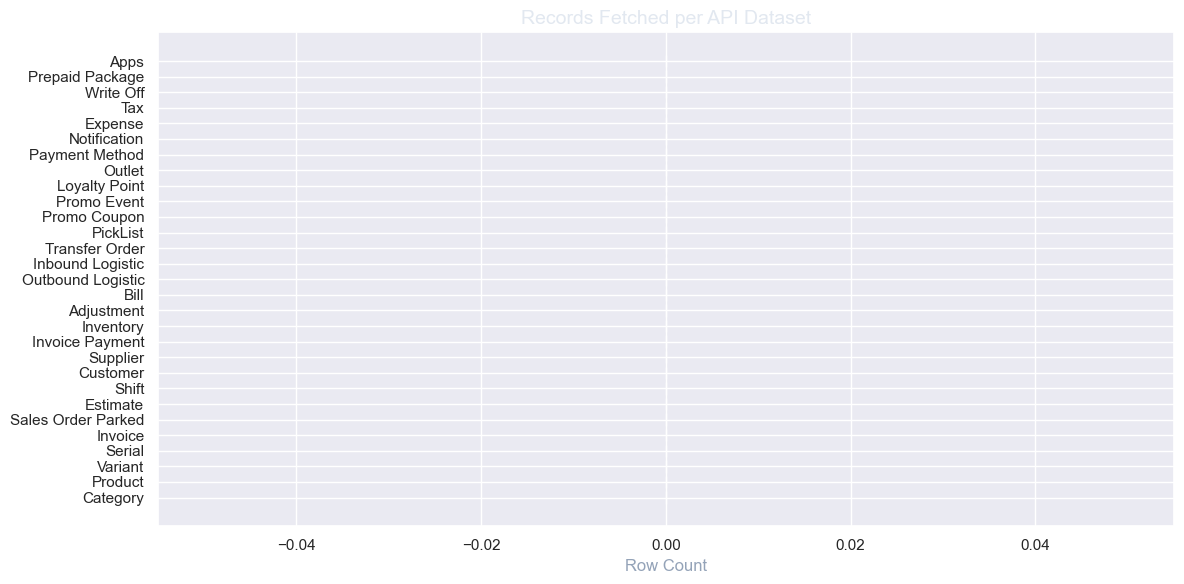


📊 Total datasets: 29
✅ With data     : 0
❌ Empty/Error   : 29


In [72]:
# Bar chart — rows per dataset

fig, ax = plt.subplots(figsize=(12, 6))

colors  = ['#10b981' if r > 0 else '#ef4444' for r in summary_df['Rows']]

ax.barh(summary_df['Dataset'], summary_df['Rows'], color=colors)

ax.set_title('Records Fetched per API Dataset', color='#e2e8f0', fontsize=14)

ax.set_xlabel('Row Count', color='#94a3b8')

plt.tight_layout()

plt.show()

print(f'\n📊 Total datasets: {len(summary_df)}')

print(f'✅ With data     : {(summary_df["Has Data"]=="✅").sum()}')

print(f'❌ Empty/Error   : {(summary_df["Has Data"]=="❌").sum()}')